     surface  best_of  tourney_level  tourney_round  a_player_age  \
5373    Hard      3.0            2.0            0.8          23.0   
5374    Hard      3.0            2.0            0.8          29.0   
5375    Hard      3.0            2.0            0.8          28.0   
5376    Hard      3.0            2.0            0.8          19.0   
5377    Hard      3.0            2.0            0.8          23.0   

      a_player_hand  a_player_ht  a_player_rank  a_player_rank_points  \
5373            1.0        180.0           15.0                1925.0   
5374            1.0        190.0           80.0                 653.0   
5375            1.0        188.0           65.0                 755.0   
5376            1.0        183.0          345.0                 122.0   
5377            1.0        183.0           89.0                 612.0   

      b_player_age  ...  a_surface_second_won_steph_rd  \
5373          28.0  ...                      60.921102   
5374          19.0  ...       

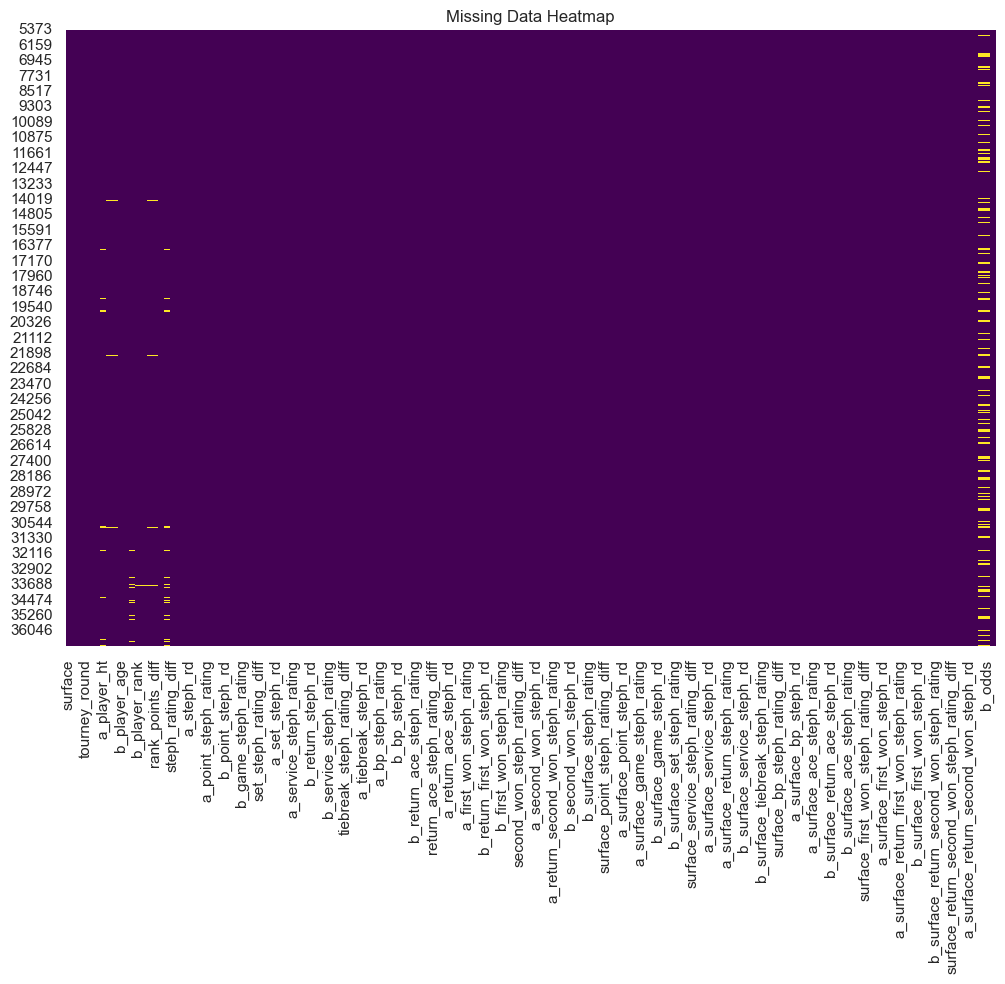

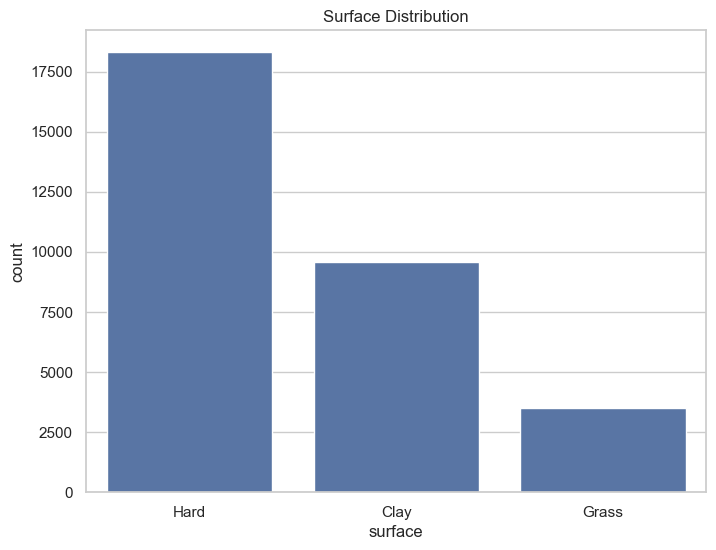

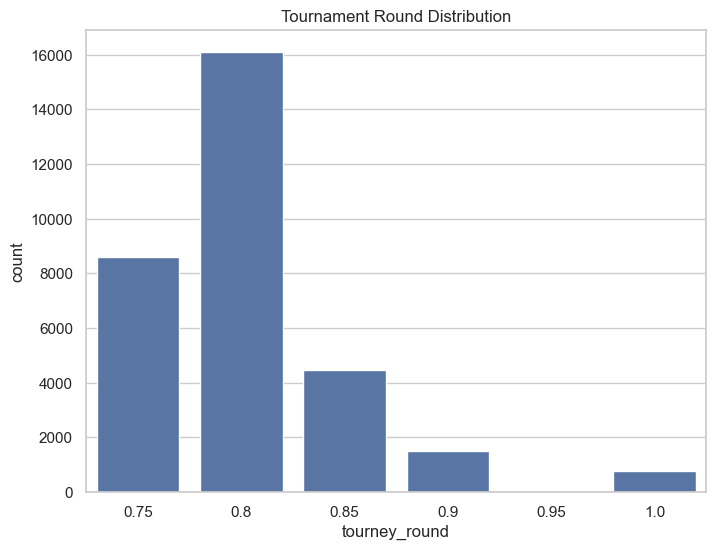

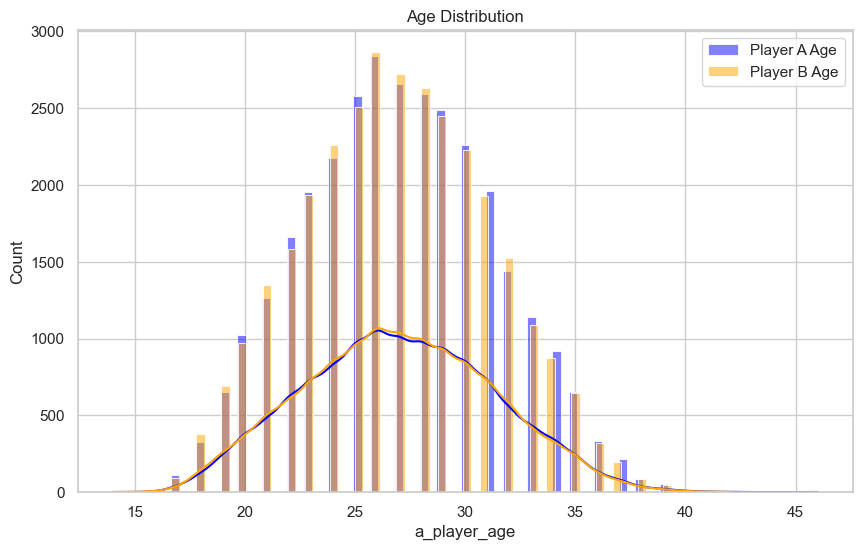

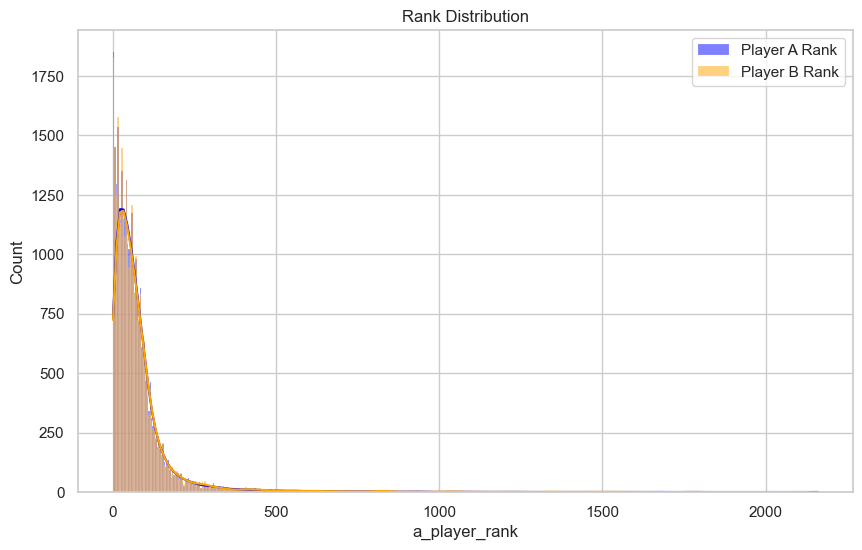

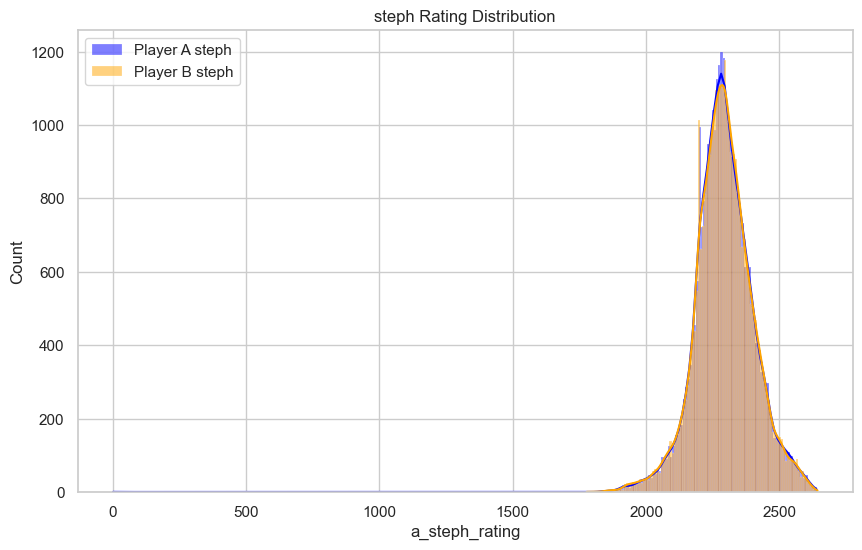

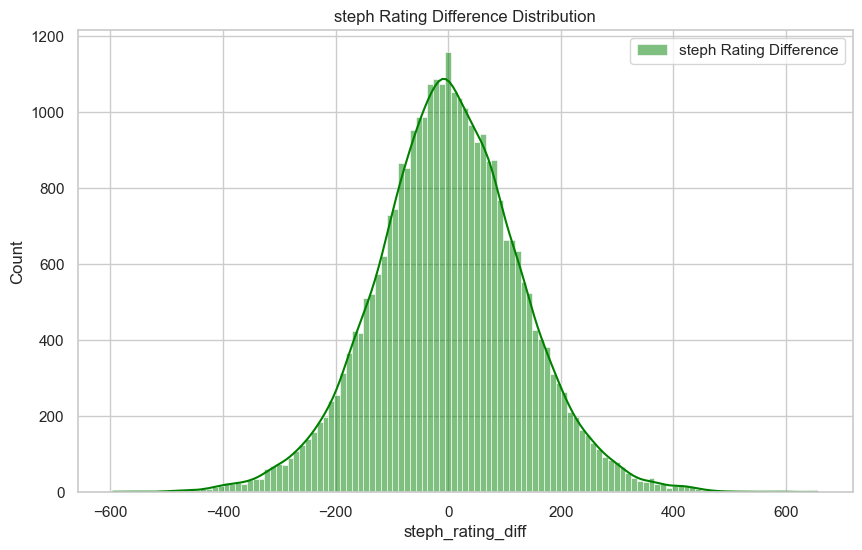

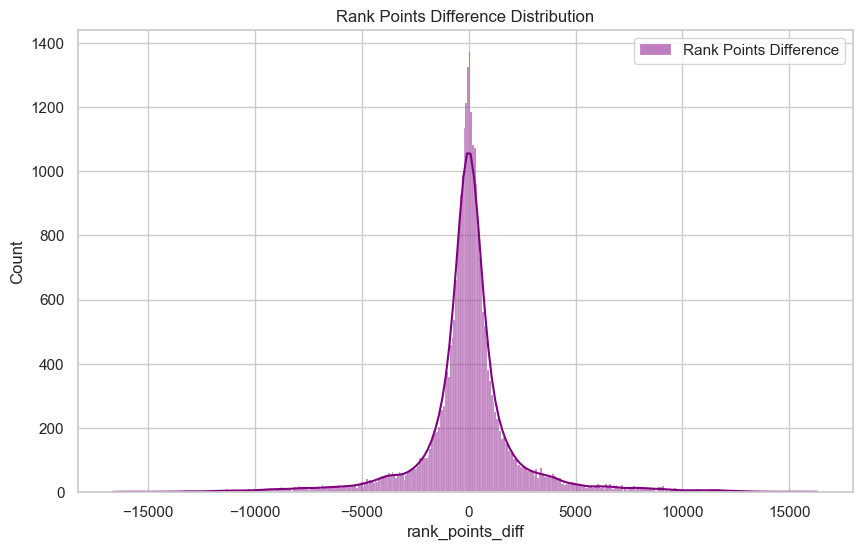

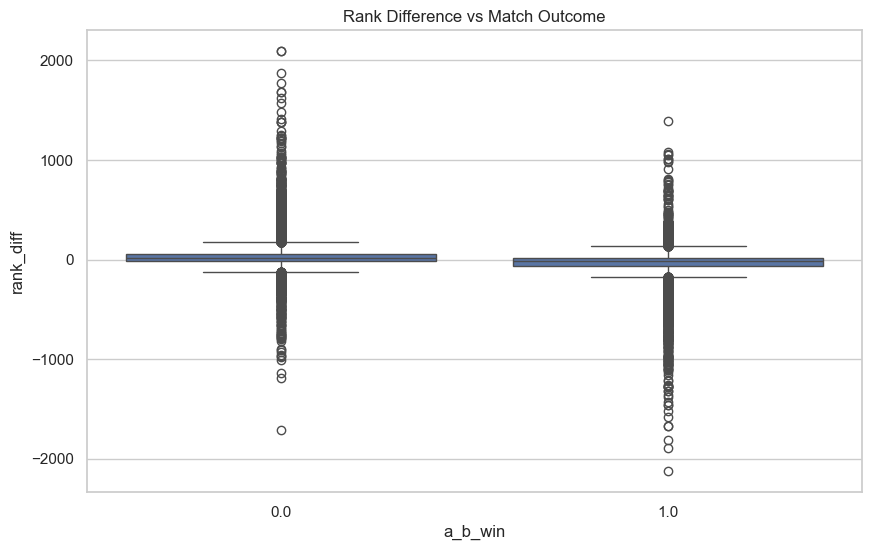

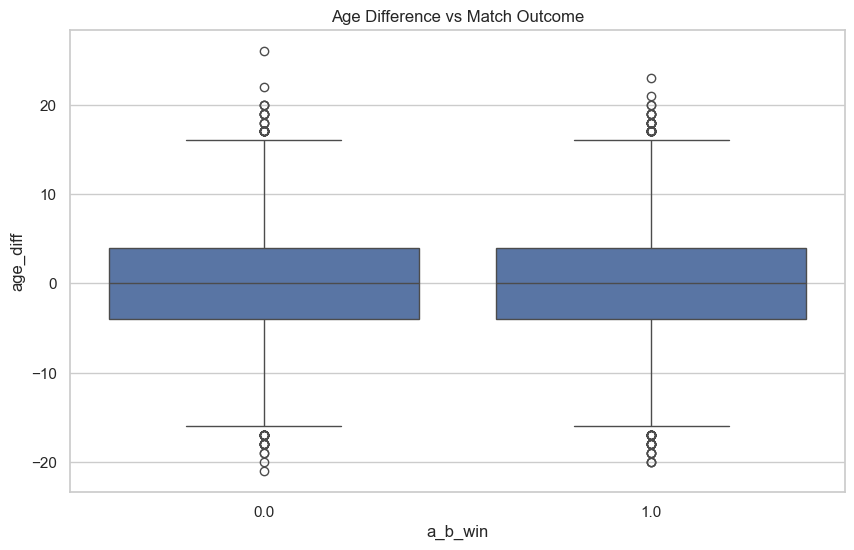

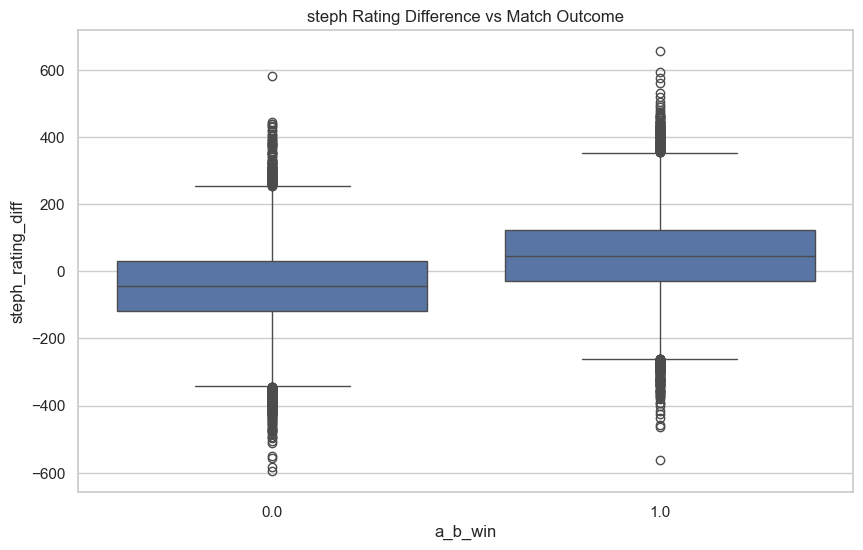

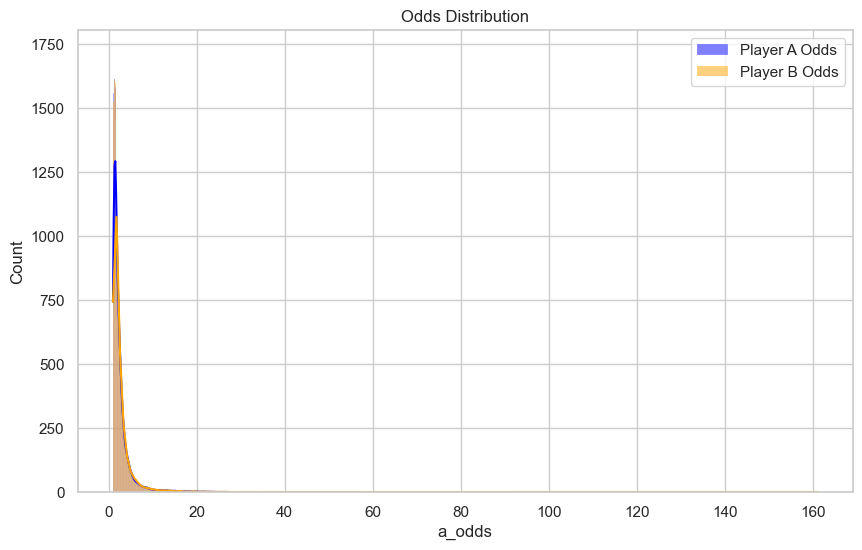

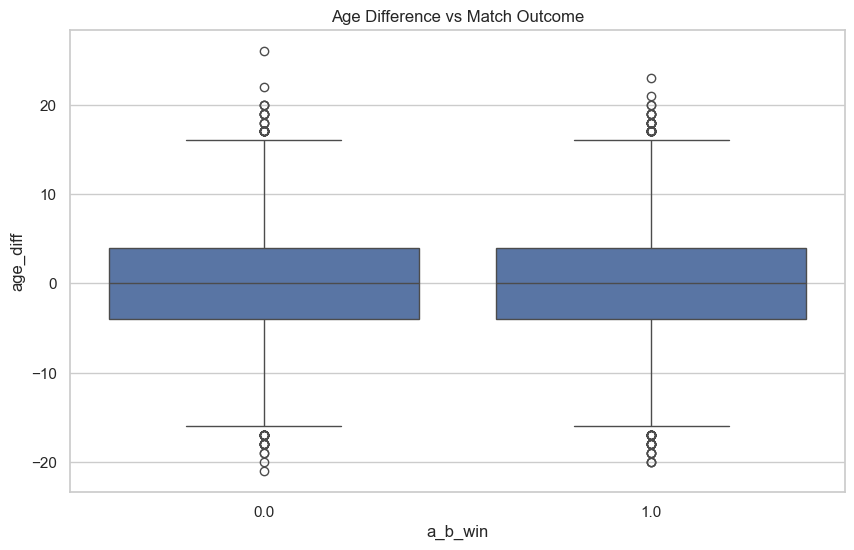

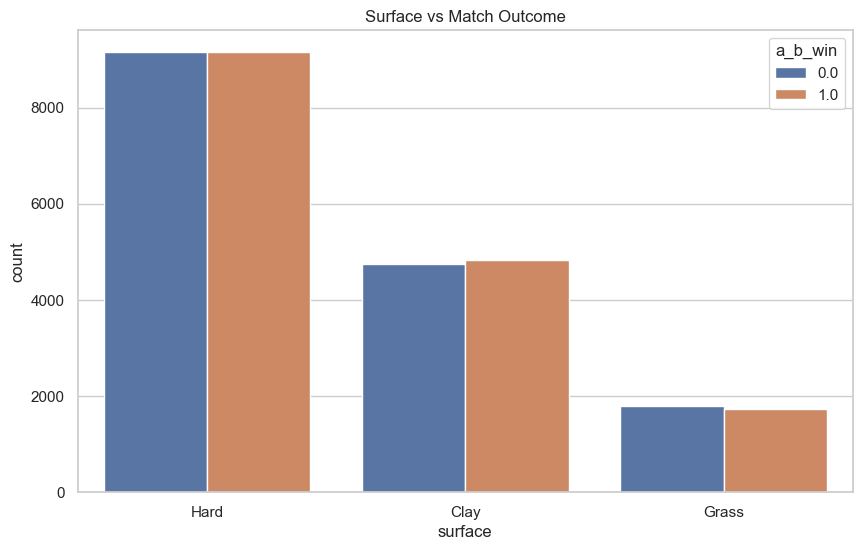

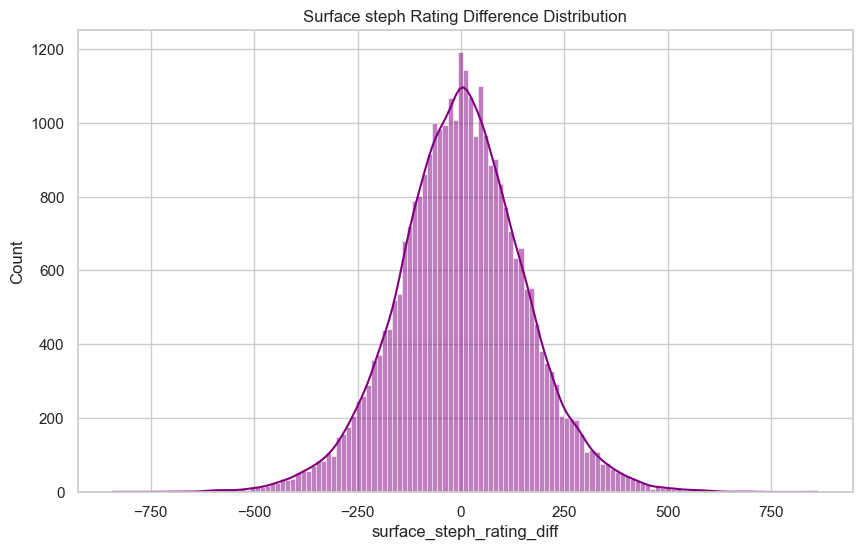

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


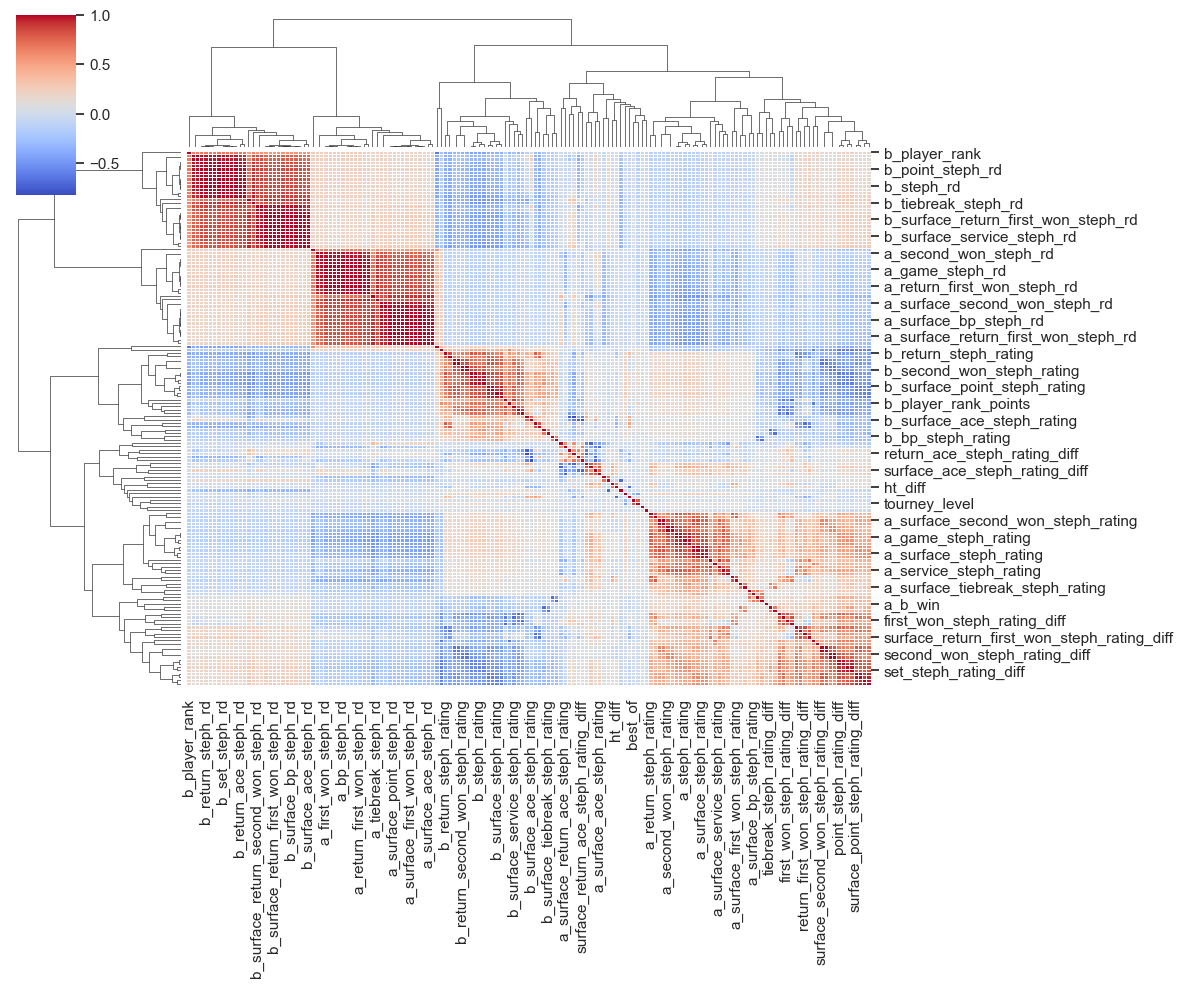

T-test for steph Rating Differences: t-statistic = 68.61442179771397, p-value = 0.0


/var/folders/ml/c9m4gk2d5j1gjzt21jgb5d3r0000gn/T/ipykernel_13164/3985477778.py:178: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(b0 + b1 * x)))


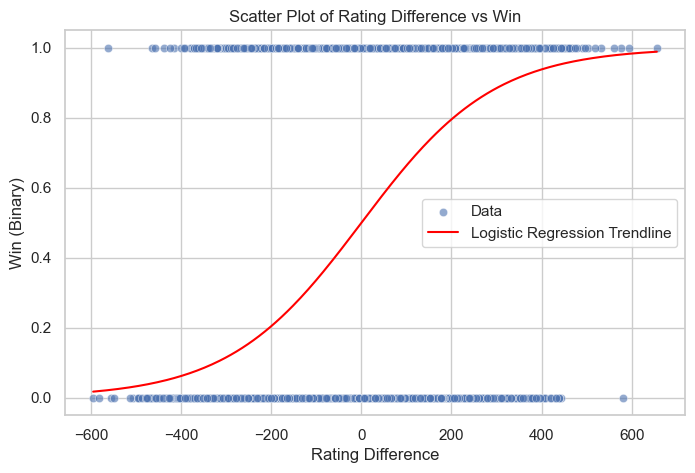

/var/folders/ml/c9m4gk2d5j1gjzt21jgb5d3r0000gn/T/ipykernel_13164/3985477778.py:178: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(b0 + b1 * x)))


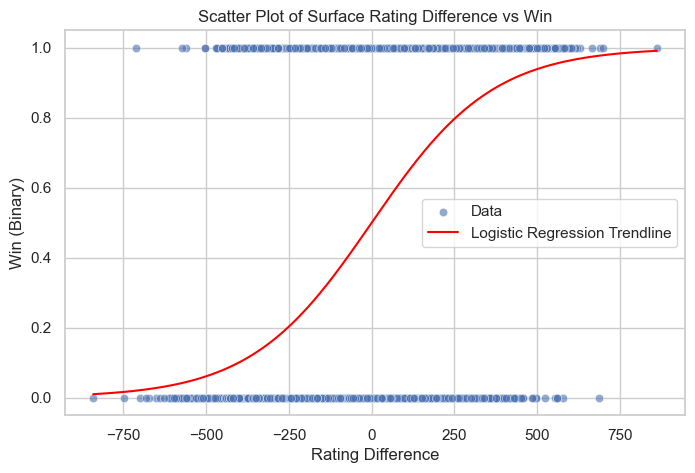

In [1]:
# File: eda_tennis_match.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from scipy.stats import ttest_ind

# Setting plot styles
sns.set(style="whitegrid")


start = '20120101'
end = '20231231'
match_type = 'm'

start_date = datetime.strptime(start, '%Y%m%d').date()
end_date = datetime.strptime(end, '%Y%m%d').date()

RD_CUTOFF = 125

df = pd.read_csv('../../testcsvs/StephFixRP25.csv')

df['tourney_date'] = pd.to_datetime(df['tourney_date']).dt.date
df = df[(df['tourney_date'] >= start_date) & (df['tourney_date'] <= end_date)]
# df = df[(df['a_surface_steph_rd'] <= RD_CUTOFF) & (df['b_surface_steph_rd'] <= RD_CUTOFF) & (df['a_steph_rd'] <= RD_CUTOFF) & (df['b_steph_rd'] <= RD_CUTOFF)]

df = df.drop(['tourney_id','match_num', 'tourney_name', 'tourney_date', 'a_player_name', 'b_player_name', 'a_player_id', 'a_player_slug', 'b_player_id', 'b_player_slug', 'sets', 'games','tiebreaks'], axis=1)


print(df.head())
print(df.info())
print(df.describe())

# 2. Missing Data
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Visualize missing data
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 3. Categorical Features
# Tourney Name
# plt.figure(figsize=(10, 6))
# sns.countplot(y='tourney_name', data=df, order=df['tourney_name'].value_counts().index)
# plt.title('Tournament Distribution')
# plt.show()

# Surface
plt.figure(figsize=(8, 6))
sns.countplot(x='surface', data=df)
plt.title('Surface Distribution')
plt.show()

# Tourney Round
plt.figure(figsize=(8, 6))
sns.countplot(x='tourney_round', data=df)
plt.title('Tournament Round Distribution')
plt.show()

# 4. Numerical Features
# Player Ages
plt.figure(figsize=(10, 6))
sns.histplot(df['a_player_age'], kde=True, color='blue', label='Player A Age')
sns.histplot(df['b_player_age'], kde=True, color='orange', label='Player B Age')
plt.title('Age Distribution')
plt.legend()
plt.show()

# Player Ranks
plt.figure(figsize=(10, 6))
sns.histplot(df['a_player_rank'], kde=True, color='blue', label='Player A Rank')
sns.histplot(df['b_player_rank'], kde=True, color='orange', label='Player B Rank')
plt.title('Rank Distribution')
plt.legend()
plt.show()

# steph Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['a_steph_rating'], kde=True, color='blue', label='Player A steph')
sns.histplot(df['b_steph_rating'], kde=True, color='orange', label='Player B steph')
plt.title('steph Rating Distribution')
plt.legend()
plt.show()

# steph Rating Differences
plt.figure(figsize=(10, 6))
sns.histplot(df['steph_rating_diff'], kde=True, color='green', label='steph Rating Difference')
plt.title('steph Rating Difference Distribution')
plt.legend()
plt.show()

# Rank Points Differences
plt.figure(figsize=(10, 6))
sns.histplot(df['rank_points_diff'], kde=True, color='purple', label='Rank Points Difference')
plt.title('Rank Points Difference Distribution')
plt.legend()
plt.show()

# 5. Player Performance Analysis
# Rank difference vs Match Outcome
plt.figure(figsize=(10, 6))
sns.boxplot(x='a_b_win', y='rank_diff', data=df)
plt.title('Rank Difference vs Match Outcome')
plt.show()

# Age difference vs Match Outcome
plt.figure(figsize=(10, 6))
sns.boxplot(x='a_b_win', y='age_diff', data=df)
plt.title('Age Difference vs Match Outcome')
plt.show()

# steph Rating Difference vs Match Outcome
plt.figure(figsize=(10, 6))
sns.boxplot(x='a_b_win', y='steph_rating_diff', data=df)
plt.title('steph Rating Difference vs Match Outcome')
plt.show()

# Odds Analysis
plt.figure(figsize=(10, 6))
sns.histplot(df['a_odds'], kde=True, color='blue', label='Player A Odds')
sns.histplot(df['b_odds'], kde=True, color='orange', label='Player B Odds')
plt.title('Odds Distribution')
plt.legend()
plt.show()

# 6. Surface-Specific Analysis
# Surface vs Match Outcome
plt.figure(figsize=(10, 6))
sns.boxplot(x='a_b_win', y='age_diff', data=df)
plt.title('Age Difference vs Match Outcome')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='surface', hue='a_b_win', data=df)
plt.title('Surface vs Match Outcome')
plt.show()

# Surface steph Rating Differences
plt.figure(figsize=(10, 6))
sns.histplot(df['surface_steph_rating_diff'], kde=True, color='purple')
plt.title('Surface steph Rating Difference Distribution')
plt.show()

# 7. Correlation Analysis
df = df.drop(columns=['surface'])

corr_matrix = df.corr()
sns.clustermap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5, figsize=(12, 10))
plt.show()


# 8. Statistical Testing
# Perform a t-test to compare steph ratings for wins vs losses
win_steph = df[df['a_b_win'] == 1]['steph_rating_diff']
loss_steph = df[df['a_b_win'] == 0]['steph_rating_diff']

t_stat, p_value = ttest_ind(win_steph, loss_steph)
print(f'T-test for steph Rating Differences: t-statistic = {t_stat}, p-value = {p_value}')

# 9. Feature Engineering
# Creating new features like experience difference (based on age), normalized rank differences, etc.
df['experience_diff'] = df['a_player_age'] - df['b_player_age']
df['normalized_rank_diff'] = df['rank_diff'] / (df['a_player_rank'] + df['b_player_rank'])


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as opt

# Define the logistic function
def logistic(x, b0, b1):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

# Fit logistic regression
x_data = df['steph_rating_diff'].values
y_data = df['a_b_win'].values

# Initial guess for parameters (intercept and coefficient)
initial_guess = [0, 1]
params, _ = opt.curve_fit(logistic, x_data, y_data, p0=initial_guess)

# Generate predictions
x_range = np.linspace(x_data.min(), x_data.max(), 300)
y_pred = logistic(x_range, *params)

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x_data, y=y_data, alpha=0.6, label='Data')
plt.plot(x_range, y_pred, color='red', label='Logistic Regression Trendline')
plt.xlabel('Rating Difference')
plt.ylabel('Win (Binary)')
plt.title('Scatter Plot of Rating Difference vs Win')
plt.legend()
plt.show()



# Fit logistic regression
x_data = df['surface_steph_rating_diff'].values
y_data = df['a_b_win'].values

# Initial guess for parameters (intercept and coefficient)
initial_guess = [0, 1]
params, _ = opt.curve_fit(logistic, x_data, y_data, p0=initial_guess)

# Generate predictions
x_range = np.linspace(x_data.min(), x_data.max(), 300)
y_pred = logistic(x_range, *params)

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x_data, y=y_data, alpha=0.6, label='Data')
plt.plot(x_range, y_pred, color='red', label='Logistic Regression Trendline')
plt.xlabel('Rating Difference')
plt.ylabel('Win (Binary)')
plt.title('Scatter Plot of Surface Rating Difference vs Win')
plt.legend()
plt.show()






# 10. Predictive Modeling Preparation
# Prepare data for modeling (e.g., logistic regression)
# Dropping non-numerical columns for simplicity
model_df = df

# Handling missing values
model_df = model_df.fillna(model_df.mean())

# Splitting data into features and target
X = model_df.drop(columns=['a_b_win'])
y = model_df['a_b_win']

# Normalize the feature data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

